In [1]:
from geostat_isoscapes_tools import geostat_utils as gutils, plot_utils as putils, sisal_utils as sutils, utils
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd 
import json
import os 
import numpy as np
import plotly.io as pio
pio.renderers.default = "vscode"

sns.set_theme(context='talk',
                  style='ticks',
                  palette='colorblind',
                  rc={'axes.linewidth':1.2,"grid.alpha":0.3,"grid.linestyle":'--'})
plt.close("all") 

In this notebook, we compare variograms of itrace and sisal data. In particular, we select itrace data with the union of circles centered around sisal points at each time slice.
Hence, we developped a function that automatically defines the mask, iterate over itrace time slices to compute their variograms, then aggregate them and save the results. 

This workflow is can be run using the script ```variogram_parameters_scan```, where all parameters can be set and looped on.
The results will automatically be saved in output folders (see logs when running).

> The original detailed workflow used before implementing the parameters scan is available in the section below

This notebook can still be useful to visualize the trend fitting results (metrics)

### Detailed workflow 

[ now superseded by script binvariogram_parameters_scan ]

In [8]:
params = {'trend': 'multiple_linear_latabs_latReLU_ele_D',
          'trend_before_mask': True,
          'maxlag': 1.2e7,
          'nlags': 20,
          'centers': None,
          'tolerance' : 22.5,
          'mask radius [km]': 75,
          'res [months]': 12*1000,
          'Itrace simulation spec' : {'time':'20kyrBP',},
          'regions':None,
          'const_coords':True
          }
data_cols = {'lat':'lat',
             'lon':'lon',
             'quantity':'d18Op'}

fp_itrace = f"../output/variograms/itrace/sim{params['Itrace simulation spec']['time']}/res{params['res [months]']}/maxlag{str(int(params['maxlag']))}nlags{params['nlags']}/trend_{params['trend']}/"
if not os.path.exists(fp_itrace) :
    os.makedirs(fp_itrace)

fp_sisal = f"../output/variograms/sisal/res{params['res [months]']}/maxlag{str(int(params['maxlag']))}nlags{params['nlags']}/trend_{params['trend']}/"
if not os.path.exists(fp_sisal) :
    os.makedirs(fp_sisal)

verbose =  False

#### Mask iTrace data around SISAL points

In [ ]:
sisal_df = gutils.get_sisal_data_for_kriging(res=int(params['res [months]']/12),regions=params['regions'],verbose=verbose)

itrace_df = gutils.get_preprocessed_itrace_data(
    data_folder='/media/luluxette/T7_Shield/pdm/iTrace/',
    res=params['res [months]'],P=True,format='df',verbose=False,
    sim_prefix = 'b.e13.Bi1850C5.f19_g16',
    sim_suffix ='100001-199912', #12:'800001-899912', #16:'400001-499912', #20 :'100001-199912',
    sim_forcings='ice_ghg_orb_wtr',
    sim_kyr= 19,
    sim_num='01',
    sim_model='clm2.h0',
    ) # pd df

loading sisal data
sisal dataframe is ready
loading itrace files
done


In [10]:
itrace_masked_df,_ = utils.mask_union_of_circles_around_pts(itrace_df,sisal_df,params['mask radius [km]'],verbose=True) # type:ignore

> computing distances between data points and anchor points
> done


In [ ]:
fig = putils.plot_global_map(data=itrace_masked_df,
                    quantity_col=data_cols['quantity'],
                    title = 'masked itrace data',
                    quantity=data_cols['quantity'],
                    unit='per mil (VSMOW)',
                    proj=False,
                    symbol='square',
                    size=10,
                    lat_col=data_cols['lat'],
                    lon_col=data_cols['lon'])

# fig.write_html("map.html", auto_open=True)
fig.show()

#### iTrace variograms

In [ ]:
for azimuth in [None] : #None,0,45,90,135
    print(f'computation dir={azimuth}')
    params['direction']=azimuth
    gutils.iterate_and_aggregate_variograms(data_ds = itrace_data, #type:ignore
                                        fp=fp_itrace,
                                        config_dict=params,
                                        data_cols=data_cols,
                                        mask_pts = sisal_df, # type:ignore
                                        verbose = verbose
                                       )

In [ ]:
dict_dfs= {
           'i_all': {'df': pd.read_csv(fp_itrace+'vario_df.csv')},
        #    'i_0': {'df': pd.read_csv(fp_itrace+'d0vario_df.csv')},
        #    'i_45': {'df': pd.read_csv(fp_itrace+'d45vario_df.csv')},
        #    'i_90': {'df': pd.read_csv(fp_itrace+'d90vario_df.csv')},
        #    'i_135': {'df': pd.read_csv(fp_itrace+'d135vario_df.csv')}
        }

model_name = 'spherical'

for key in dict_dfs.keys():
    dict_dfs[key]['params'],dict_dfs[key]['fct_fitted'],dict_dfs[key]['pcov'] = gutils.fit_variogram_model(bin_edges=dict_dfs[key]['df']['lag'], # type:ignore
                                                                                gammas=dict_dfs[key]['df']['gamma'],
                                                                                model_name=model_name,
                                                                                pair_counts=dict_dfs[key]['df']['count']
                                                                                ) 

In [ ]:
fig,ax = putils.plot_variogram_from_bins_and_gamma(bin_edges=np.asarray(dict_dfs['i_all']['df']['lag'].values),
                                          gamma=np.asarray(dict_dfs['i_all']['df']['gamma'].values),
                                          title='iTrace dataset - 11.7 to 11 ky BP - weighted average',
                                          counts=np.asarray(dict_dfs['i_all']['df']['count']),
                                          plot_model=True,
                                          model_name=model_name,
                                          model_fct=dict_dfs['i_all']['fct_fitted'],
                                          model_params=dict_dfs['i_all']['params'],
                                          figsize=(10,5),
                                          save_name=fp_itrace+'fig.png'
                                          ) # type:ignore
plt.show()
plt.close('all')

In [ ]:
list_dir = [0,45,90,135]
ranges=[]
fig,axes = plt.subplots(2,2,figsize=(20,10))
for i in range(2):
    for j in range(2):
        key = f'i_{list_dir[j+2*i]}'
        axes[i,j] = putils.plot_variogram_from_bins_and_gamma(bin_edges=np.asarray(dict_dfs[key]['df']['lag'].values),
                                                            gamma=np.asarray(dict_dfs[key]['df']['gamma'].values),
                                                            title='iTrace dataset - 11.7 to 11 ky BP - weighted average',
                                                            counts=np.asarray(dict_dfs[key]['df']['count'].values),
                                                            plot_model=True,
                                                            model_name=model_name,
                                                            model_fct=dict_dfs[key]['fct_fitted'],
                                                            model_params=dict_dfs[key]['params'],
                                                            figsize=(10,5),
                                                            ax_ = axes[i,j]
                                                            #     save_name='../output/variograms/fig_global_variogram_and_model_chen.png'
                                                            ) # type:ignore
        axes[i,j].set_title(f'dir={list_dir[j+2*i]}')
        ranges.append(dict_dfs[key]['params']['range'])
        
plt.show()
plt.close('all')

for dir, r in zip(list_dir, ranges):
    print(f'Range in direction {dir}°: {r :.2e} m')
anisotropy_ratio = max(ranges) / min(ranges)
print(f'Anisotropy Ratio: {anisotropy_ratio}')
max_range_index = ranges.index(max(ranges))
print(f'Anisotropy Direction: {list_dir[max_range_index]}°')

#### SISAL variograms

In [ ]:
sisal_df_valid = sisal_df.loc[(sisal_df['binned_age']>=19000)&(sisal_df['binned_age']<20000),['binned_age','lat','lon','site_id','d18Op_VSMOW_exactconv']].copy() #type:ignore

In [ ]:
putils.plot_global_map(data=sisal_df_valid[sisal_df_valid['binned_age']==19000], #type:ignore
                       lon_col='lon',
                       lat_col='lat',   
                       quantity_col='d18Op_VSMOW_exactconv',
                       unit='per mil (VSMOW)',
                       proj=True,
                       title='SISAL 19-20 kyr BP'
                       )

In [ ]:
params['direction']=None
params['const_coords']=False
gutils.iterate_and_aggregate_variograms(data = sisal_df_valid.rename(columns={'d18Op_VSMOW_exactconv':'d18Op','binned_age':'time'}), #type:ignore
                                        fp=fp_sisal,
                                        config_dict=params,
                                        data_cols=data_cols,
                                        mask_pts = None, # type:ignore
                                        verbose = False
                                       )

### Variography results  

In [3]:
# First, we open the output files of the variogram computations (iTraCE)

with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
    itrace_sims = json.load(f)

list_df =[]
list_metrics = []
list_vario_itrace = []
list_vario_sisal=[]

res = 200 # months
for yrBP in itrace_sims.keys():
    if yrBP != '_comment':
        folder_exp = f'../output/variograms/2026-04-14_itrace_wd18O/'
        fp = f'{folder_exp}itrace/sim{yrBP}kyrBP/res{res}/maxlag10000000nlags10/trend_multiple_linear_lat_latquad_ele_D/sisal_mask_2000km/' ### PUT PATH HERE 
        fp_sisal = f'{folder_exp}sisal/slice{yrBP}kyrBP/res{res}/maxlag10000000nlags10/trend_multiple_linear_lat_latquad_ele_D/' ### PUT PATH HERE 
        
        with open(fp+'trend_metricsNone.json', 'r') as f: # 'None' refers to the (un)directionality of the variogram ('azimuth' in parameters scan)
            results_dict = json.load(f)
        for i,t in enumerate(list(results_dict.keys())):
            t_num = int(float(t))
            df, metrics = gutils.multiple_linear_result_dict_to_df(results_dict[t])
            metrics['time']= t_num
            df['time']= t_num
            df['r2']=results_dict[t]['r2']
            df['r2adj']=results_dict[t]['adj_r2']
            df['mae']=results_dict[t]['mae']
            list_df.append(df)
            list_metrics.append(metrics)
            # Load vario SISAL
            with open(f'{fp_sisal}variogram_params_None_t{t_num}.json', 'r') as f:
                vario_params_sisal = json.load(f)
            vario_params_sisal['time'] = t_num
            list_vario_sisal.append(pd.DataFrame([vario_params_sisal]))
            # Load vario iTraCE
            with open(f'{fp}variogram_params_None_t{t_num}.json', 'r') as f:
                vario_params_itrace = json.load(f)
            vario_params_itrace['time'] = t_num
            list_vario_itrace.append(pd.DataFrame([vario_params_itrace]))
result_df = pd.concat(list_df).reset_index(drop=True)
metrics_df = pd.concat(list_metrics).reset_index(drop=True)
vario_itrace_df = pd.concat(list_vario_itrace).reset_index(drop=True)
vario_sisal_df = pd.concat(list_vario_sisal).reset_index(drop=True)

#### Investigation of trend models coefficients and metrics

In [4]:
print('Mean MAE :',np.mean(result_df['mae']))
print('Mean r2 :',np.mean(result_df['r2']))
print('Mean r2adj :',np.mean(result_df['r2adj']))
print('std MAE :',np.std(result_df['mae']))
print('std r2 :',np.std(result_df['r2']))
print('std r2adj :',np.std(result_df['r2adj']))

Mean MAE : 2.795128131371628
Mean r2 : 0.9170360050863073
Mean r2adj : 0.9169816512599475
std MAE : 0.17605950475024734
std r2 : 0.00658261729042437
std r2adj : 0.006585260951033151


In [5]:
metrics_df.loc[metrics_df['name']=='D','vif'].mean()

np.float64(1.1838592242356754)

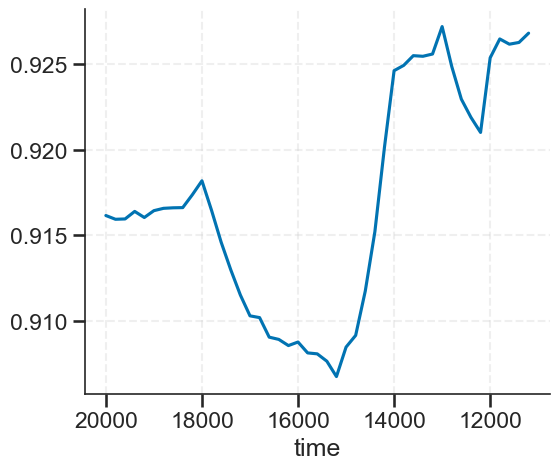

In [6]:
fig,ax = plt.subplots(figsize=(6,5))
result_df.groupby('time')['r2adj'].mean().plot(ax=ax)
sns.despine()
plt.grid(linestyle='--',alpha=0.3)
ax.invert_xaxis()
plt.show()
# plt.scatter(result_df['time'],result_df['r2adj'])

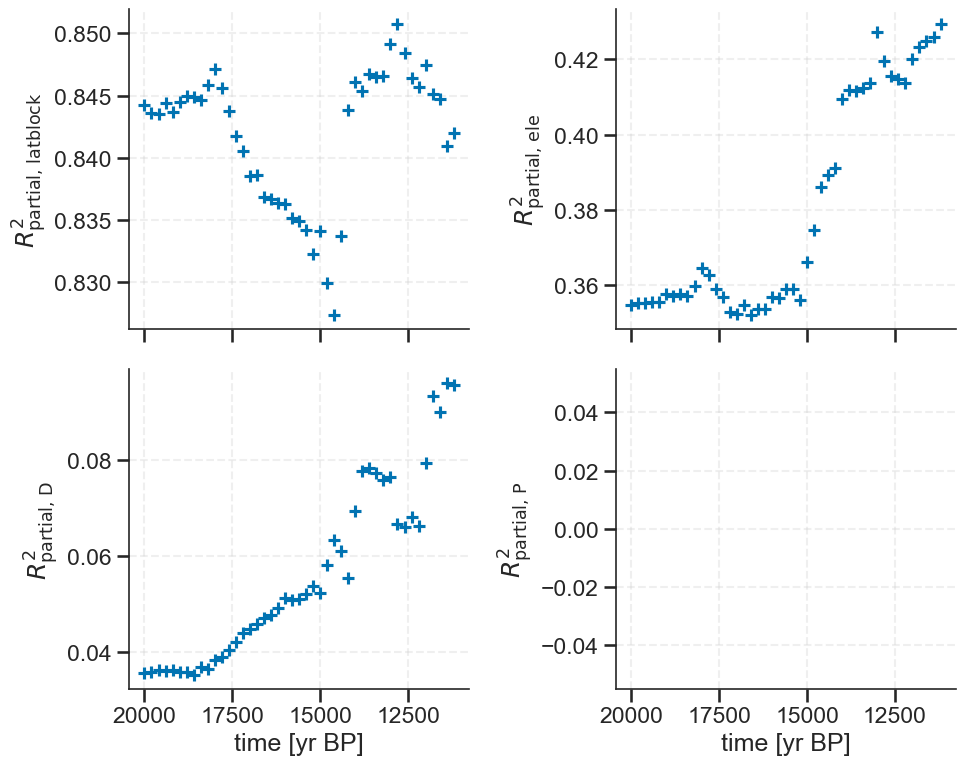

In [7]:
fig,axes = plt.subplots(2,2,sharex=True,figsize=(10,8))
for i,pred in enumerate(['latblock','ele','D','P']):
    ax = axes[i//2,i%2]
    ax.scatter(metrics_df.loc[metrics_df.name==pred,'time'].values,metrics_df.loc[metrics_df.name==pred,'partial r2'].values,marker='+',label=pred)
    ax.set_ylabel(rf'$R^2_\text{{partial, {pred}}}$')
    ax.grid(linestyle='--',alpha=0.3)

axes[1,1].set_xlabel('time [yr BP]')
axes[1,0].set_xlabel('time [yr BP]')
sns.despine()
axes[0,0].invert_xaxis()

plt.tight_layout()
# plt.savefig('../output/trendmodel_partial_r2_allpredictors.png',dpi=500)
plt.show()


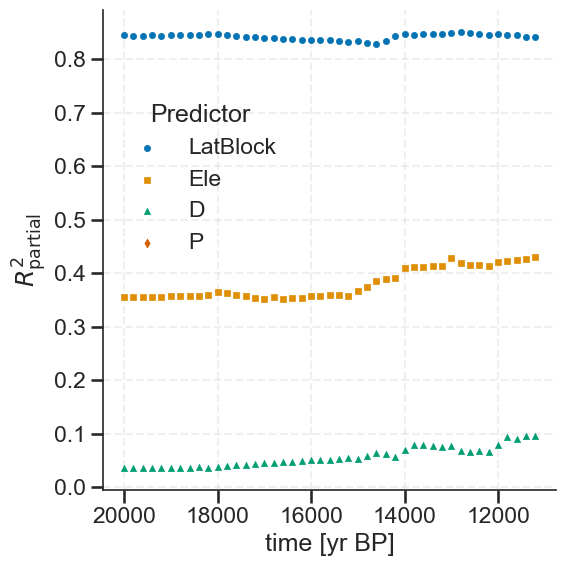

In [8]:
fig, ax = plt.subplots(figsize=(6,6))
preds = ['latblock','ele','D','P']
preds_name = ['LatBlock','Ele','D','P']
colors = sns.color_palette("colorblind", n_colors=len(preds))
markers = ['o','s','^','d']

for p, c, m in zip(preds, colors, markers):
    sub = metrics_df.loc[metrics_df.name == p]
    ax.scatter(sub['time'].values, sub['partial r2'].values, label=preds_name[preds.index(p)], color=c, marker=m, s=20,linewidths=0.5)

ax.set_ylabel(r'$R^2_{\mathrm{partial}}$')
ax.set_xlabel('time [yr BP]')
ax.grid(which='both',linestyle='--', alpha=0.3)
ax.locator_params(axis='y', nbins=10)
ax.invert_xaxis()
ax.legend(title='Predictor', loc='center left', bbox_to_anchor=(0, 0.65), frameon=False)
sns.despine()
plt.tight_layout()
# plt.savefig('../output/trendmodel_partial_r2_allpredictors_singleax.png', dpi=300)
plt.show()

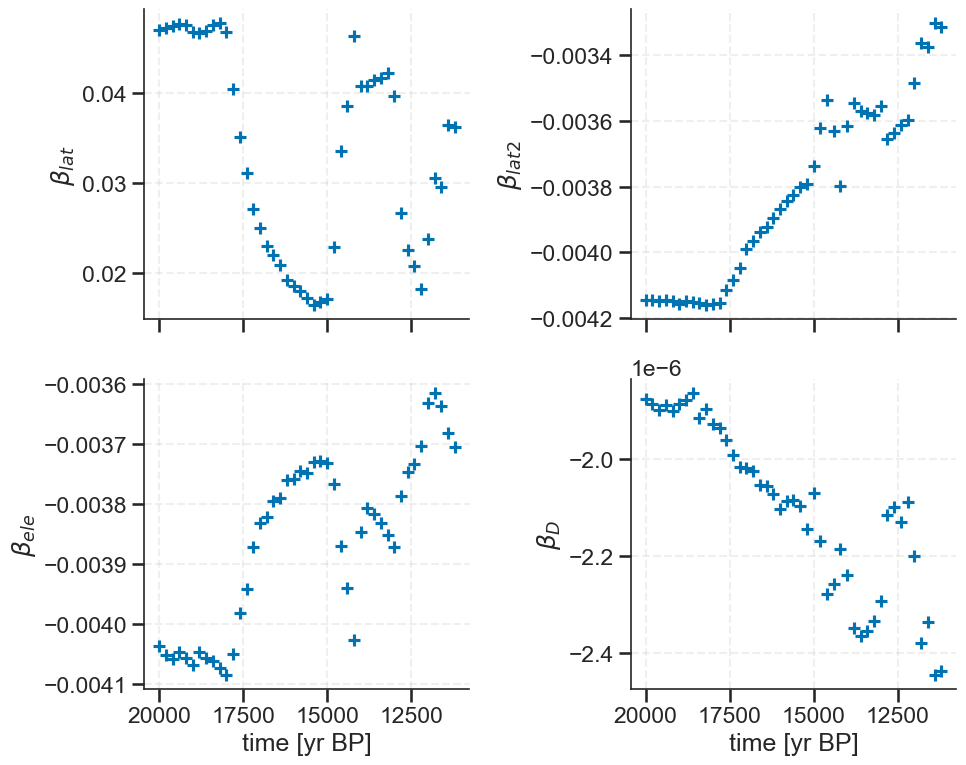

In [9]:
fig,axes = plt.subplots(2,2,sharex=True,figsize=(10,8))
for i,pred in enumerate(['lat','lat2','ele','D']):
    ax = axes[i//2,i%2]
    ax.scatter(result_df.loc[result_df.name==pred,'time'].values,result_df.loc[result_df.name==pred,'beta'].values,marker='+',label=pred)
    ax.set_ylabel(rf'$\beta_{{{pred}}}$')
    ax.grid(linestyle='--',alpha=0.3)

axes[1,1].set_xlabel('time [yr BP]')
axes[1,0].set_xlabel('time [yr BP]')
sns.despine()
axes[0,0].invert_xaxis()

plt.tight_layout()
# plt.savefig('../output/trendmodel_partial_r2_allpredictors.png',dpi=500)
plt.show()


In [31]:
# from matplotlib.ticker import MaxNLocator

# fig,axes = plt.subplots(2,2,sharex=True,figsize=(10,8))
# for i,pred in enumerate(['lat','lat2','ele','D']):
#     ax = axes[i//2,i%2]
#     ax.scatter(result_df.loc[result_df.name==pred,'time'].values,result_df.loc[result_df.name==pred,'beta'].values,marker='+',label=pred)
#     ax.set_ylabel(rf'$\beta_{{{pred}}}$')
#     ax.grid(linestyle='--',alpha=0.3)

# axes[1,1].set_xlabel('time [yr BP]')
# axes[1,0].set_xlabel('time [yr BP]')
# sns.despine()
# axes[0,0].invert_xaxis()

# axes[0,0].xaxis.set_major_locator(MaxNLocator(nbins=5))
# plt.tight_layout()
# plt.savefig('../output/trendmodel_coefficients_sisal.png',dpi=500)
# plt.show()

#### Investigation of variogram parameters

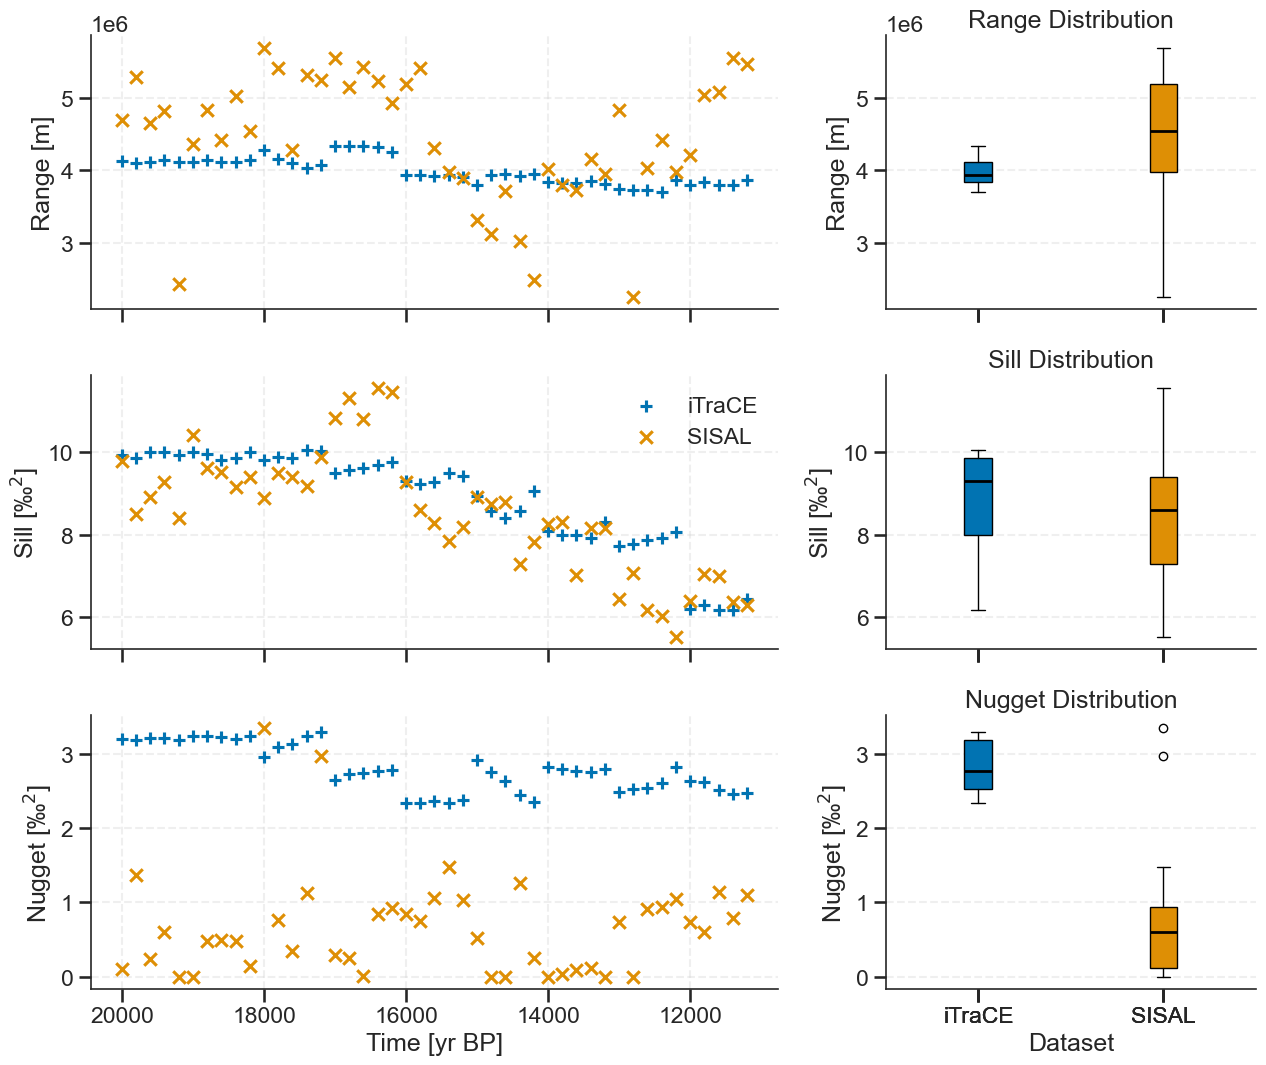

In [10]:
fig, axes = plt.subplots(3,2,figsize=(13,11),sharex='col',gridspec_kw={'width_ratios': [0.65, 0.35]})

# Left column: Scatter plots over time
axes[0,0].scatter(vario_itrace_df['time'].values,vario_itrace_df['range_spherical'].values,marker='+',label='iTraCE')
axes[0,0].scatter(vario_sisal_df['time'].values,vario_sisal_df['range_spherical'].values,marker='x',label='SISAL')
axes[0,0].set_ylabel('Range [m]')
axes[1,0].scatter(vario_itrace_df['time'].values,vario_itrace_df['sill_spherical'].values,marker='+',label='iTraCE')
axes[1,0].scatter(vario_sisal_df['time'].values,vario_sisal_df['sill_spherical'].values,marker='x',label='SISAL')
axes[1,0].set_ylabel(r'Sill [‰$^2$]')
axes[2,0].scatter(vario_itrace_df['time'].values,vario_itrace_df['nugget'].values,marker='+',label='iTraCE')
axes[2,0].scatter(vario_sisal_df['time'].values,vario_sisal_df['nugget'].values,marker='x',label='SISAL')
axes[2,0].set_ylabel(r'Nugget [‰$^2$]')
axes[2,0].set_xlabel('Time [yr BP]')
axes[1,0].legend(frameon=False)

# Right column: Boxplots comparing distributions
params_list = ['range_spherical', 'sill_spherical', 'nugget']
labels_list = ['Range', 'Sill', 'Nugget']
ylabels_lists = [['Range [m]'], [r'Sill [‰$^2$]'], [r'Nugget [‰$^2$]']]
colors = sns.color_palette("colorblind", 2)
for i, (param, label) in enumerate(zip(params_list, labels_list)):
    data_to_plot = [vario_itrace_df[param].dropna(), vario_sisal_df[param].dropna()]
    bp = axes[i,1].boxplot(data_to_plot, tick_labels=['iTraCE', 'SISAL'], patch_artist=True)
    
    # Color the boxes to match the scatter plot colors
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # Color the median lines black
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)
    
    axes[i,1].set_ylabel(ylabels_lists[i][0])
    axes[i,1].grid(axis='y', linestyle='--', alpha=0.3)
    axes[i,1].set_title(f'{label} Distribution')

axes[2,1].set_xlabel('Dataset')

# Apply styling to all subplots
sns.despine(top=True,right=True)
axes[0,0].invert_xaxis()
axes[0,0].grid()
axes[1,0].grid()
axes[2,0].grid()

plt.tight_layout()
# plt.savefig('../output/results_figs/fig_variogram_params_over_time.png',dpi=500)
plt.show()

#### Variogram plot for ESSD 

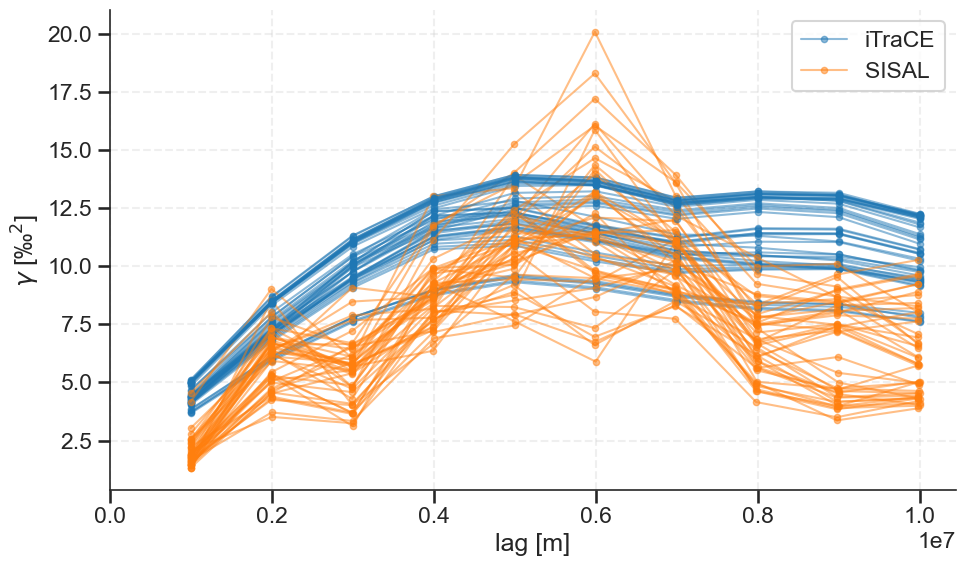

In [11]:
res = 200
folder_exp = "../output/variograms/2026-04-14_itrace_wd18O/"

fig, ax = plt.subplots(figsize=(10, 6))

for yrBP in itrace_sims.keys():
    if yrBP != '_comment':
        fp = f'{folder_exp}itrace/sim{yrBP}kyrBP/res{res}/maxlag10000000nlags10/trend_multiple_linear_lat_latquad_ele_D/sisal_mask_2000km/'
        fp_sisal = f'{folder_exp}sisal/slice{yrBP}kyrBP/res{res}/maxlag10000000nlags10/trend_multiple_linear_lat_latquad_ele_D/'
        
        # Load and plot iTrace gammas in blue 'x-'
        itrace_vario = pd.read_csv(fp + 'vario_None_df_all_iterations.csv')
        for t,vario_t in itrace_vario.groupby('time_slice') :
            ax.plot(vario_t['lag'], vario_t['gamma'], '.-', linewidth=1.5,alpha=0.5,color='tab:blue',label='iTraCE' if t==20000 else None)
        
        # Load and plot SISAL gammas in orange '+-'
        sisal_vario = pd.read_csv(fp_sisal + 'vario_None_df_all_iterations.csv')
        for t,vario_t in sisal_vario.groupby('time_slice') :
            ax.plot(vario_t['lag'], vario_t['gamma'], '.-',linewidth=1.5, alpha=0.5,color='tab:orange',label='SISAL' if t ==20000 else None)

ax.set_xlabel('lag [m]')
ax.set_xlim(0)
ax.set_ylabel(r'$\gamma$ [‰$^2$]')
# ax.set_title('SISAL and iTrace empirical residual variograms over 20-11 ka')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
ax.legend()
plt.tight_layout()
plt.show()

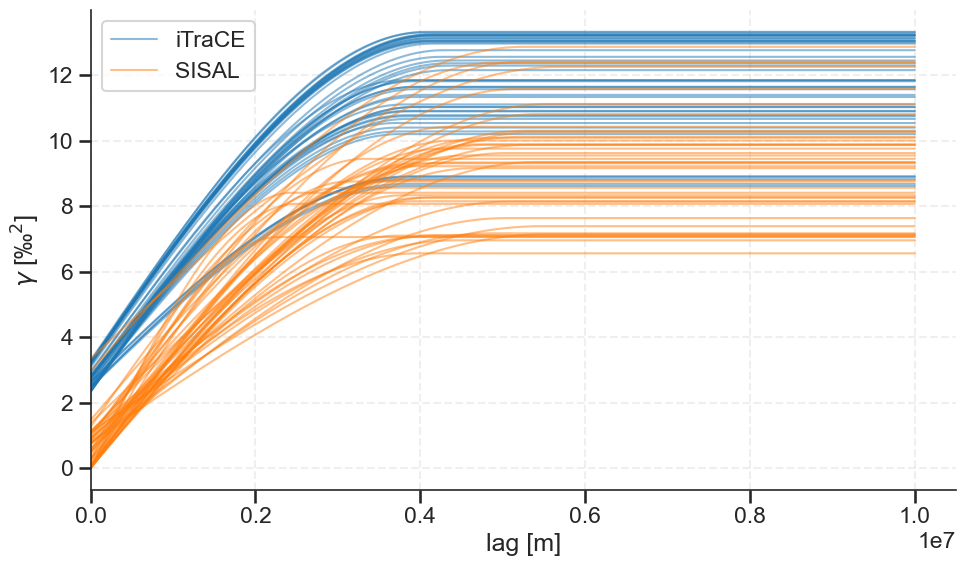

In [20]:
from geostat_isoscapes_tools import variogram_models

model = variogram_models.CompositeModel('spherical+nugget')
lags = np.linspace(start=0,stop=1e7,num=200)

fig, ax = plt.subplots(figsize=(10, 6))

for t,vario_t in vario_itrace_df.groupby('time'):
    ax.plot(lags,model.get_model_func()(lags,vario_t['range_spherical'].values[0],vario_t['sill_spherical'].values[0],vario_t['nugget'].values[0]), '-', linewidth=1.5,alpha=0.5,color='tab:blue',label='iTraCE' if t==20000 else None)

for t,vario_t in vario_sisal_df.groupby('time') :
    ax.plot(lags,model.get_model_func()(lags,vario_t['range_spherical'].values[0],vario_t['sill_spherical'].values[0],vario_t['nugget'].values[0]), '-', linewidth=1.5,alpha=0.5,color='tab:orange',label='SISAL' if t==20000 else None)

ax.set_xlabel('lag [m]')
ax.set_xlim(0)
ax.set_ylabel(r'$\gamma$ [‰$^2$]')
# ax.set_title('SISAL and iTrace empirical residual variograms over 20-11 ka')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
ax.legend()
plt.tight_layout()
plt.show()

## Climatological variograms

In [1]:
from geostat_isoscapes_tools import geostat_utils as gutils, plot_utils as putils, sisal_utils as sutils, utils
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd 
import json
import os 
import numpy as np
import plotly.io as pio
pio.renderers.default = "vscode"

sns.set_theme(context='talk',
                  style='ticks',
                  palette='colorblind',
                  rc={'axes.linewidth':1.2,"grid.alpha":0.3,"grid.linestyle":'--'})
plt.close("all") 

In [2]:
# DATA
# load d18O data 
d18O_df = gutils.get_preprocessed_itrace_data(res=200*12,data_folder='../data/iTraCE/')
# keep only relevant columns
d18O_subdf = d18O_df[['d18Op','lat','lon','time']].copy() #type:ignore
# remove any lat-lon-time duplicates (because the binning of time did not aggregate the samples that belonged to the same time bin)
d18O_subdf = d18O_subdf.drop_duplicates(subset=['lat','lon','time'])

loading itrace files
This dataset contains  12000  time steps.
   bins of width=2400 months (200 years)
   converting xr to DataFrame (~2 minutes)
itrace_df ready


In [3]:
# REMOVE TRENDS 
trend = 'multiple_linear_lat_latquad_ele_D'
to_add = ['ele','D']
cols_exog = np.unique(np.array(to_add)).tolist()
cols_exog.extend(['lat','lon'])
exog_df = gutils.add_external_variables_to_lonlat_df(d18O_subdf,variables=to_add,verbose=False)[cols_exog] # type:ignore
d18O_subdf = d18O_subdf.merge(exog_df,on=['lat','lon']) # type:ignore
d18O_subdf = d18O_subdf.dropna(axis=0) # clean nans that come from exog variables

for t, df_t in d18O_subdf.groupby('time'):
    print(f'removing trend for time {t}...')
    d18O_subdf.loc[df_t.index, 'resid'],_ = gutils.trend_removal(trend,df_t,'d18Op',verbose=False)

removing trend for time 0.0...
removing trend for time 2400.0...
removing trend for time 4800.0...
removing trend for time 7200.0...
removing trend for time 9600.0...


In [4]:
# CLIMATOLOGICAL VARIOGRAM from Bastin et al. 1984 :
# 1. Compute the variance of the field for each time step
S2k = d18O_subdf.groupby('time',observed=True)['resid'].std() # spatial standard deviation of the residuals at each time slice

# 2. Standardize the observations by the spatial variance 
d18O_subdf['resid_standardized']=d18O_subdf.apply(lambda row: row['resid'] / S2k.loc[row['time']], axis=1) # type:ignore

# 3. Compute variogram on standardized values 
bin_counts, gammas, ref_bins, trend_result = gutils.iterative_variogram_computations(data=d18O_subdf,
                                                                                    quantity='resid_standardized',
                                                                                    maxlag=1.2e7,
                                                                                    nlags=20,
                                                                                    )

100%|██████████| 5/5 [00:04<00:00,  1.02it/s]


In [9]:
# fit a variogram model to the variograms at each time step 
model = 'spherical+nugget'
for i,t in enumerate(d18O_subdf.time.unique()):
    params,fitted_fct,pcov = gutils.fit_variogram_model(bin_edges=ref_bins, # type:ignore
                                                            gammas=gammas[i],
                                                            model_name=model,
                                                            bounds=(np.array([0,0,0]),np.array([1e8,2,2]))
                                                            )
    print(params)
    

{'range_spherical': np.float64(4948238.545755679), 'sill_spherical': np.float64(0.7672102455918653), 'nugget': np.float64(0.1353643663493674)}
{'range_spherical': np.float64(5080844.441318969), 'sill_spherical': np.float64(0.7740757822733018), 'nugget': np.float64(0.14181960538952834)}
{'range_spherical': np.float64(5113203.18244392), 'sill_spherical': np.float64(0.771647299305837), 'nugget': np.float64(0.1407021134943589)}
{'range_spherical': np.float64(5355842.399921954), 'sill_spherical': np.float64(0.7803793706720462), 'nugget': np.float64(0.15990363363500723)}
{'range_spherical': np.float64(5325931.28165051), 'sill_spherical': np.float64(0.7719002606235451), 'nugget': np.float64(0.16239518450375873)}


In [ ]:
# For the nugget : 
# - either assume it is constant in time, as beta, and scales with alpha(k) : alpha(k)*(c0+gamma(beta))
# - or that it a fixed constant noise plateau, so i add it externally as in "c0'+ alpha(k)*gamma(beta)"
# - or i decompose it into two different supparts c0'' + alpha(k)*(C0''' + gamma(beta)) 

#For now i will scale it with alpha(k) to see whether the results are consistent

# Now I can keep one range parameter only and one nugget parameter only to define the g_m(beta) de Bastin et al-


# and now i can solve the kriging system with the g_m(beta) vario because the lambda_i do not depend on the alpha parameter.
#